In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import *
from modules.CliffsDelta import cliffsDelta
from tabulate import tabulate
from IPython.display import display, HTML

In [5]:
def plot_box_plot(long_df):
    if long_df["Group"].unique().shape[0] > 2:
        custom_palette = {
            'Noise-Free Buggy': '#ff7f0e',        # red
            'Noise-Free NotBuggy': '#1f77b4',    # blue
            'Noisy Buggy': '#d62728',         # orange
            'Noisy NotBuggy': '#2ca02c'      # green
        }
    else:
        custom_palette = {
            'Noise-Free Buggy': '#ff7f0e',        # red
            'Noise-Free NotBuggy': '#1f77b4',    # blue
            'Noisy Buggy': '#ff7f0e',         # orange
            'Noisy NotBuggy': '#1f77b4'      # green
        }
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=long_df, x='Metric', y='Value', hue='Group', palette=custom_palette)
    plt.yscale('log')
    plt.ylabel('Value')
    plt.legend(title='Group', loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=4)
    plt.tight_layout()
    plt.show()


# Illustration of distributions for a project

In [3]:
project_name = "sonarqube"
noise_free_dir = f"./data/NoiseFreeDataset/{project_name}.csv"
noisy_dir = f"./data/NoisyDataset/{project_name}.csv"

#cols = ["SLOCStandard", "Readability", "McCabe", "totalFanOut", "MaintainabilityIndex"]
cols = ["Size", "Readability", "McCabe", "FanOut", "MI"]
rename_cols = {'SLOCStandard': 'Size', 'totalFanOut': 'FanOut', 'MaintainabilityIndex': 'MI'}

In [4]:
noise_free_df = pd.read_csv(noise_free_dir).rename(columns=rename_cols)
noise_free_buggy = noise_free_df[noise_free_df["Detection"] == "Buggy"][cols]
noise_free_notbuggy = noise_free_df[noise_free_df["Detection"] == "NotBuggy"][cols]

noisy_df = pd.read_csv(noisy_dir).rename(columns=rename_cols)
noisy_buggy = noisy_df[noisy_df["Decision"] == "Buggy"][cols]
noisy_notbuggy = noisy_df[noisy_df["Decision"] == "NotBuggy"][cols]

noise_free_buggy["Group"] = "Noise-Free Buggy"
noise_free_notbuggy["Group"] = "Noise-Free NotBuggy"
noisy_buggy["Group"] = "Noisy Buggy"
noisy_notbuggy["Group"] = "Noisy NotBuggy"

combined_df_noise_free = pd.concat([noise_free_notbuggy, noise_free_buggy])
long_df_noise_free = combined_df_noise_free.melt(id_vars='Group', var_name='Metric', value_name='Value')

combined_df_noisy = pd.concat([noisy_notbuggy, noisy_buggy])
long_df_noisy = combined_df_noisy.melt(id_vars='Group', var_name='Metric', value_name='Value')

combined_df = pd.concat([noisy_notbuggy, noise_free_notbuggy, noisy_buggy, noise_free_buggy])
long_df = combined_df.melt(id_vars='Group', var_name='Metric', value_name='Value')

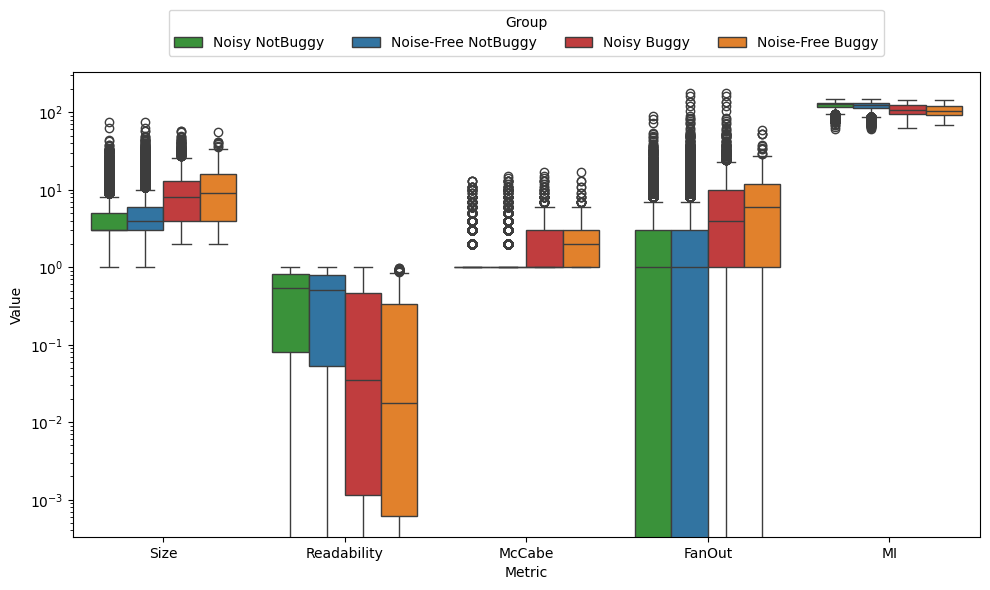

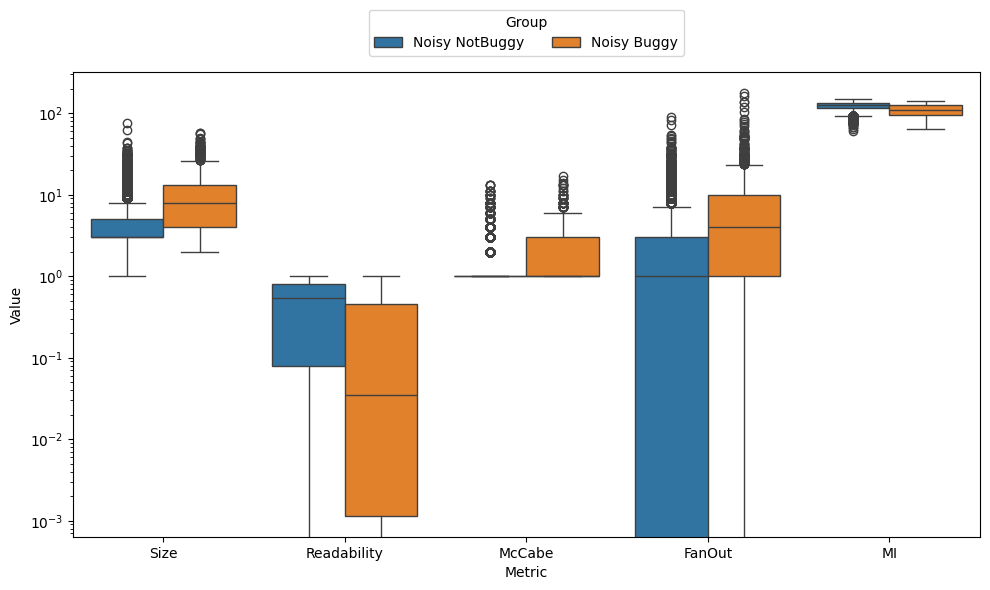

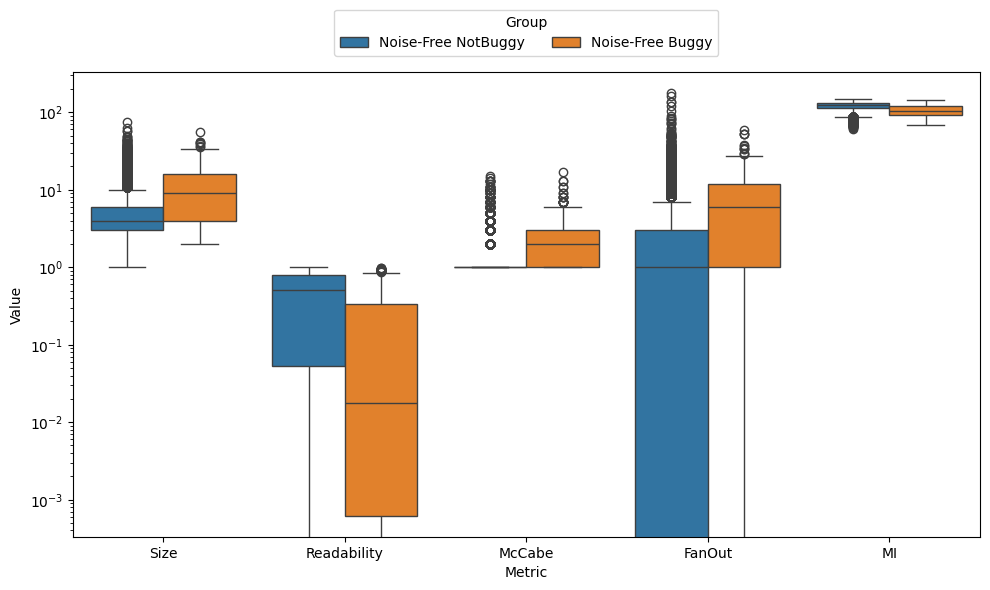

In [5]:
plot_box_plot(long_df)
plot_box_plot(long_df_noisy)
plot_box_plot(long_df_noise_free)

# Analyisis of distributions

In [2]:
noise_free_dir = f"./data/NoiseFreeDataset/"
noisy_dir = f"./data/NoisyDataset/"

cols = ["Size", "Readability", "McCabe", "FanOut", "MI"]
rename_cols = {'SLOCStandard': 'Size', 'totalFanOut': 'FanOut', 'MaintainabilityIndex': 'MI'}

## Noisy: Buggy vs NotBuggy

In [3]:
results_wrst = []
results_cd = []

all_files = [f for f in os.listdir(noisy_dir) if f.endswith(".csv")]

method_count = []

for file in all_files:
    df = pd.read_csv(os.path.join(noisy_dir, file)).rename(columns=rename_cols)

    noisy_buggy = df[df["Decision"] == "Buggy"][cols].copy()
    noisy_notbuggy = df[df["Decision"] == "NotBuggy"][cols].copy()


    res_wrst = {"Project": file.replace('.csv', '')}
    res_wrst["#Methods"] = len(noisy_buggy) + len(noisy_notbuggy)

    for col in cols:
        z_stat, p_value = ranksums(noisy_buggy[col], noisy_notbuggy[col])
        is_diff = p_value < 0.05
        res_wrst[col] = is_diff
    results_wrst.append(res_wrst)


    res_cd = {"Project": file.replace('.csv', '')}
    res_cd["#Methods"] = len(noisy_buggy) + len(noisy_notbuggy)

    for col in cols:
        if noisy_buggy.shape[0] == 0 or noisy_notbuggy.shape[0] == 0:
            size = "undefined"
        else:
            d, size = cliffsDelta(noisy_buggy[col], noisy_notbuggy[col])
        res_cd[col] = size
    results_cd.append(res_cd)

wrst_results_df = pd.DataFrame(results_wrst)

true_percentages_all = wrst_results_df.drop(["Project", "#Methods"], axis=1).mean() * 100
true_percentages_df_all = true_percentages_all.reset_index()
true_percentages_df_all.columns = ['column', 'All']
true_percentages_df_all = true_percentages_df_all.set_index('column').T

true_percentages_t20 = wrst_results_df.sort_values(by=["#Methods"], ascending=False).head(20).drop(["Project", "#Methods"], axis=1).mean() * 100
true_percentages_df_t20 = true_percentages_t20.reset_index()
true_percentages_df_t20.columns = ['column', 'Top 20']
true_percentages_df_t20 = true_percentages_df_t20.set_index('column').T

wrst = pd.concat([true_percentages_df_all, true_percentages_df_t20]).round(2)
print("Wilcoxon rank sum test to show the percentage of cases where Buggy vs NotBuggy exhibit statistically significantly different on the Actual Dataset")
print(tabulate(wrst, headers='keys', tablefmt='pretty'))
print()


cd_results_df = pd.DataFrame(results_cd)

# All projects
res = []
for col in cols:
    percentage = pd.DataFrame(cd_results_df[col].value_counts(normalize=True) * 100)
    res.append({
        'Metric': col,
        'Negligible': percentage.loc["negligible"]["proportion"] if "negligible" in percentage.index else 0,
        'Small': percentage.loc["small"]["proportion"] if "small" in percentage.index else 0,
        'Medium': percentage.loc["medium"]["proportion"] if "medium" in percentage.index else 0,
        'Large': percentage.loc["large"]["proportion"] if "large" in percentage.index else 0,
    })
cdelta = pd.DataFrame(res).round(2)

print("Cliff's Delta to show the percentage where Buggy vs NotBuggy exhibit different effect size on the Actual Dataset")
print(tabulate(cdelta, headers='keys', tablefmt='pretty', showindex=False))

Wilcoxon rank sum test to show the percentage of cases where Buggy vs NotBuggy exhibit statistically significantly different on the Actual Dataset
+--------+-------+-------------+--------+--------+-------+
|        | Size  | Readability | McCabe | FanOut |  MI   |
+--------+-------+-------------+--------+--------+-------+
|  All   | 95.92 |    91.84    | 95.92  | 97.96  | 95.92 |
| Top 20 | 100.0 |    100.0    | 100.0  | 100.0  | 100.0 |
+--------+-------+-------------+--------+--------+-------+

Cliff's Delta to show the percentage where Buggy vs NotBuggy exhibit different effect size on the Actual Dataset
+-------------+------------+-------+--------+-------+
|   Metric    | Negligible | Small | Medium | Large |
+-------------+------------+-------+--------+-------+
|    Size     |    0.0     | 14.29 | 46.94  | 36.73 |
| Readability |    2.04    | 36.73 | 42.86  | 16.33 |
|   McCabe    |    2.04    | 34.69 | 36.73  | 24.49 |
|   FanOut    |    0.0     | 10.2  | 46.94  | 40.82 |
|     M

/tmp/ipykernel_994489/1991109072.py:19: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  z_stat, p_value = ranksums(noisy_buggy[col], noisy_notbuggy[col])


## Noise-Free: Buggy vs NotBuggy

In [3]:
results_wrst = []
results_cd = []

all_files = [f for f in os.listdir(noise_free_dir) if f.endswith(".csv")]

method_count = []

for file in all_files:
    df = pd.read_csv(os.path.join(noise_free_dir, file)).rename(columns=rename_cols)

    noise_free_buggy = df[df["Detection"] == "Buggy"][cols].copy()
    noise_free_notbuggy = df[df["Detection"] == "NotBuggy"][cols].copy()


    res_wrst = {"Project": file.replace('.csv', '')}
    res_wrst["#Methods"] = len(noise_free_buggy) + len(noise_free_notbuggy)

    for col in cols:
        z_stat, p_value = ranksums(noise_free_buggy[col], noise_free_notbuggy[col])
        is_diff = p_value < 0.05
        res_wrst[col] = is_diff
    results_wrst.append(res_wrst)


    res_cd = {"Project": file.replace('.csv', '')}
    res_cd["#Methods"] = len(noise_free_buggy) + len(noise_free_notbuggy)

    for col in cols:
        if noise_free_buggy.shape[0] == 0 or noise_free_notbuggy.shape[0] == 0:
            size = "undefined"
        else:
            d, size = cliffsDelta(noise_free_buggy[col], noise_free_notbuggy[col])
        res_cd[col] = size
    results_cd.append(res_cd)

wrst_results_df = pd.DataFrame(results_wrst)

true_percentages_all = wrst_results_df.drop(["Project", "#Methods"], axis=1).mean() * 100
true_percentages_df_all = true_percentages_all.reset_index()
true_percentages_df_all.columns = ['column', 'All']
true_percentages_df_all = true_percentages_df_all.set_index('column').T

true_percentages_t20 = wrst_results_df.sort_values(by=["#Methods"], ascending=False).head(20).drop(["Project", "#Methods"], axis=1).mean() * 100
true_percentages_df_t20 = true_percentages_t20.reset_index()
true_percentages_df_t20.columns = ['column', 'Top 20']
true_percentages_df_t20 = true_percentages_df_t20.set_index('column').T

wrst = pd.concat([true_percentages_df_all, true_percentages_df_t20]).round(2)
print("Wilcoxon rank sum test to show the percentage of cases where Buggy vs NotBuggy exhibit statistically significantly different on the Noise-Free Dataset")
print(tabulate(wrst, headers='keys', tablefmt='pretty'))
print()


cd_results_df = pd.DataFrame(results_cd)

# All projects
res = []
for col in cols:
    percentage = pd.DataFrame(cd_results_df[col].value_counts(normalize=True) * 100)
    res.append({
        'Metric': col,
        'Negligible': percentage.loc["negligible"]["proportion"] if "negligible" in percentage.index else 0,
        'Small': percentage.loc["small"]["proportion"] if "small" in percentage.index else 0,
        'Medium': percentage.loc["medium"]["proportion"] if "medium" in percentage.index else 0,
        'Large': percentage.loc["large"]["proportion"] if "large" in percentage.index else 0,
    })
cd = pd.DataFrame(res).round(2)

print("Cliff's Delta to show the percentage where Buggy vs NotBuggy exhibit different effect size on the Noise-Free Dataset")
print(tabulate(cd, headers='keys', tablefmt='pretty', showindex=False))

Wilcoxon rank sum test to show the percentage of cases where Buggy vs NotBuggy exhibit statistically significantly different on the Noise-Free Dataset
+--------+-------+-------------+--------+--------+-------+
|        | Size  | Readability | McCabe | FanOut |  MI   |
+--------+-------+-------------+--------+--------+-------+
|  All   | 97.96 |    93.88    | 97.96  | 100.0  | 97.96 |
| Top 20 | 100.0 |    100.0    | 100.0  | 100.0  | 100.0 |
+--------+-------+-------------+--------+--------+-------+

Cliff's Delta to show the percentage where Buggy vs NotBuggy exhibit different effect size on the Noise-Free Dataset
+-------------+------------+-------+--------+-------+
|   Metric    | Negligible | Small | Medium | Large |
+-------------+------------+-------+--------+-------+
|    Size     |    0.0     | 6.12  | 20.41  | 73.47 |
| Readability |    2.04    | 24.49 | 40.82  | 32.65 |
|   McCabe    |    2.04    | 8.16  | 42.86  | 46.94 |
|   FanOut    |    0.0     | 6.12  | 22.45  | 71.43 |

# Analysis of the **Buggy** distributions for all 49 project

In [2]:
noise_free_dir = f"./data/NoiseFreeDataset/"
noisy_dir = f"./data/NoisyDataset/"

cols = ["Size", "Readability", "McCabe", "FanOut", "MI"]
rename_cols = {'SLOCStandard': 'Size', 'totalFanOut': 'FanOut', 'MaintainabilityIndex': 'MI'}

## Wilcoxon Rank Sum Test: Is there any difference?

In [4]:
wrst_results = []
all_files = [f for f in os.listdir(noise_free_dir) if f.endswith(".csv")]

for file in all_files:
    noisy_buggy = pd.read_csv(os.path.join(noisy_dir, file)).rename(columns=rename_cols)
    noisy_buggy = noisy_buggy[noisy_buggy["Decision"] == "Buggy"][cols].copy()
    
    noise_free_buggy = pd.read_csv(os.path.join(noise_free_dir, file)).rename(columns=rename_cols)
    noise_free_buggy = noise_free_buggy[noise_free_buggy["Detection"] == "Buggy"][cols].copy()

    res = {"Project": file.replace('.csv', '')}
    res["#Methods"] = len(noisy_buggy) + len(noise_free_buggy)

    for col in cols:
        z_stat, p_value = ranksums(noisy_buggy[col], noise_free_buggy[col])
        is_diff = p_value < 0.05
        res[col] = is_diff
    wrst_results.append(res)

wrst_results_df = pd.DataFrame(wrst_results)
wrst_results_df

,Project,#Methods,Size,Readability,McCabe,FanOut,MI
0,spring-boot,201,False,True,False,True,True
1,guava,838,True,False,True,True,True
2,pmd,984,True,False,True,True,True
3,hbase,1513,False,False,False,False,False
4,ant,470,False,False,False,False,False
5,lucene-solr,1264,True,True,True,True,True
6,jna,242,False,False,False,False,False
7,spring-framework,370,False,True,False,False,False
8,sonarqube,1728,True,False,True,True,True
9,voldemort,625,False,False,False,False,False


In [5]:
true_percentages_all = wrst_results_df.drop(["Project", "#Methods"], axis=1).mean() * 100
true_percentages_df_all = true_percentages_all.reset_index()
true_percentages_df_all.columns = ['column', 'All']
true_percentages_df_all = true_percentages_df_all.set_index('column').T

true_percentages_t20 = wrst_results_df.sort_values(by=["#Methods"], ascending=False).head(20).drop(["Project", "#Methods"], axis=1).mean() * 100
true_percentages_df_t20 = true_percentages_t20.reset_index()
true_percentages_df_t20.columns = ['column', 'Top 20']
true_percentages_df_t20 = true_percentages_df_t20.set_index('column').T

percentage_wrst = pd.concat([true_percentages_df_all, true_percentages_df_t20]).round(2)
print("Wilcoxon rank sum test to show the percentage of cases where Noisy Buggy vs Noise-Free Buggy exhibit statistically significantly different")
print(tabulate(percentage_wrst, headers='keys', tablefmt='pretty'))

Wilcoxon rank sum test to show the percentage of cases where Noisy Buggy vs Noise-Free Buggy exhibit statistically significantly different
+--------+------+-------------+--------+--------+-------+
|        | Size | Readability | McCabe | FanOut |  MI   |
+--------+------+-------------+--------+--------+-------+
|  All   | 44.9 |    36.73    |  44.9  |  44.9  | 48.98 |
| Top 20 | 75.0 |    55.0     |  75.0  |  75.0  | 80.0  |
+--------+------+-------------+--------+--------+-------+


## Cliff's Delta: How different are they?

In [3]:
cd_results = []
all_files = [f for f in os.listdir(noise_free_dir) if f.endswith(".csv")]

for file in all_files:
    noisy_buggy = pd.read_csv(os.path.join(noisy_dir, file)).rename(columns=rename_cols)
    noisy_buggy = noisy_buggy[noisy_buggy["Decision"] == "Buggy"][cols].copy()
    
    noise_free_buggy = pd.read_csv(os.path.join(noise_free_dir, file)).rename(columns=rename_cols)
    noise_free_buggy = noise_free_buggy[noise_free_buggy["Detection"] == "Buggy"][cols].copy()


    res = {"Project": file.replace('.csv', '')}
    res["#Methods"] = len(noisy_buggy) + len(noise_free_buggy)

    for col in cols:
        d, size = cliffsDelta(noisy_buggy[col], noise_free_buggy[col])
        res[col] = size
    cd_results.append(res)

cd_results_df = pd.DataFrame(cd_results)

cd_results_df

,Project,#Methods,Size,Readability,McCabe,FanOut,MI
0,spring-boot,201,small,small,negligible,small,small
1,guava,838,negligible,negligible,negligible,negligible,negligible
2,pmd,984,small,negligible,negligible,small,small
3,hbase,1513,negligible,negligible,negligible,negligible,negligible
4,ant,470,negligible,negligible,negligible,negligible,negligible
5,lucene-solr,1264,small,negligible,small,negligible,small
6,jna,242,negligible,negligible,negligible,negligible,negligible
7,spring-framework,370,negligible,negligible,negligible,negligible,negligible
8,sonarqube,1728,negligible,negligible,small,negligible,negligible
9,voldemort,625,negligible,negligible,negligible,negligible,negligible


In [4]:
# All projects
res = []
for col in cols:
    percentage = pd.DataFrame(cd_results_df[col].value_counts(normalize=True) * 100)
    res.append({
        'Type' : "All",
        'Metric': col,
        'Negligible': percentage.loc["negligible"]["proportion"] if "negligible" in percentage.index else 0,
        'Small': percentage.loc["small"]["proportion"] if "small" in percentage.index else 0,
        'Medium': percentage.loc["medium"]["proportion"] if "medium" in percentage.index else 0,
        'Large': percentage.loc["large"]["proportion"] if "large" in percentage.index else 0,
    })

# Top 20 projects by number of methods
top20 = cd_results_df.sort_values(by=["#Methods"], ascending=False).head(20)
for col in cols:
    percentage = pd.DataFrame(top20[col].value_counts(normalize=True) * 100)
    res.append({
        'Type' : "Top 20",
        'Metric': col,
        'Negligible': percentage.loc["negligible"]["proportion"] if "negligible" in percentage.index else 0,
        'Small': percentage.loc["small"]["proportion"] if "small" in percentage.index else 0,
        'Medium': percentage.loc["medium"]["proportion"] if "medium" in percentage.index else 0,
        'Large': percentage.loc["large"]["proportion"] if "large" in percentage.index else 0,
    })
percentage_cd = pd.DataFrame(res).round(2)
print(tabulate(percentage_cd, headers='keys', tablefmt='pretty', showindex=False))

+--------+-------------+------------+-------+--------+-------+
|  Type  |   Metric    | Negligible | Small | Medium | Large |
+--------+-------------+------------+-------+--------+-------+
|  All   |    Size     |   69.39    | 30.61 |   0    |   0   |
|  All   | Readability |    89.8    | 10.2  |   0    |   0   |
|  All   |   McCabe    |   65.31    | 34.69 |   0    |   0   |
|  All   |   FanOut    |   67.35    | 32.65 |   0    |   0   |
|  All   |     MI      |   67.35    | 32.65 |   0    |   0   |
| Top 20 |    Size     |    65.0    | 35.0  |   0    |   0   |
| Top 20 | Readability |    95.0    |  5.0  |   0    |   0   |
| Top 20 |   McCabe    |    60.0    | 40.0  |   0    |   0   |
| Top 20 |   FanOut    |    65.0    | 35.0  |   0    |   0   |
| Top 20 |     MI      |    65.0    | 35.0  |   0    |   0   |
+--------+-------------+------------+-------+--------+-------+


## Analysis of the Buggy distribution for the projects that has significant diffrence

In [3]:
NUM_METRICS_NEED_TO_DIFFER = 5

In [4]:
results = []
all_files = [f for f in os.listdir(noise_free_dir) if f.endswith(".csv")]

files = []
for file in all_files:
    noisy_buggy = pd.read_csv(os.path.join(noisy_dir, file)).rename(columns=rename_cols)
    noisy_buggy = noisy_buggy[noisy_buggy["Decision"] == "Buggy"][cols].copy()
    
    noise_free_buggy = pd.read_csv(os.path.join(noise_free_dir, file)).rename(columns=rename_cols)
    noise_free_buggy = noise_free_buggy[noise_free_buggy["Detection"] == "Buggy"][cols].copy()

    cnt = 0
    for col in cols:
        z_stat, p_value = ranksums(noisy_buggy[col], noise_free_buggy[col])
        if p_value < 0.05:
            cnt = cnt + 1
    
    if cnt >= NUM_METRICS_NEED_TO_DIFFER:
        files.append(file)


print(f"For {len(files)} project, at least {NUM_METRICS_NEED_TO_DIFFER} metrics are different between Noise-Free Buggy and Noisy Buggy.")

for file in files:
    noisy_buggy = pd.read_csv(os.path.join(noisy_dir, file)).rename(columns=rename_cols)
    noisy_buggy = noisy_buggy[noisy_buggy["Decision"] == "Buggy"][cols].copy()
    
    noise_free_buggy = pd.read_csv(os.path.join(noise_free_dir, file)).rename(columns=rename_cols)
    noise_free_buggy = noise_free_buggy[noise_free_buggy["Detection"] == "Buggy"][cols].copy()


    res = {"Project": file.replace('.csv', '')}
    res["#Methods"] = len(noisy_buggy) + len(noise_free_buggy)

    for col in cols:
        d, size = cliffsDelta(noisy_buggy[col], noise_free_buggy[col])
        res[col] = size
    results.append(res)


stat_results_df = pd.DataFrame(results)

res = []
for col in cols:
    percentage = pd.DataFrame(stat_results_df[col].value_counts(normalize=True) * 100)
    res.append({
        'Metric': col,
        'Negligible': percentage.loc["negligible"]["proportion"] if "negligible" in percentage.index else 0,
        'Small': percentage.loc["small"]["proportion"] if "small" in percentage.index else 0,
        'Medium': percentage.loc["medium"]["proportion"] if "medium" in percentage.index else 0,
        'Large': percentage.loc["large"]["proportion"] if "large" in percentage.index else 0,
    })
percentage_df = pd.DataFrame(res).round(2)
print(tabulate(percentage_df, headers='keys', tablefmt='pretty', showindex=False))

For 16 project, at least 5 metrics are different between Noise-Free Buggy and Noisy Buggy.
+-------------+------------+-------+--------+-------+
|   Metric    | Negligible | Small | Medium | Large |
+-------------+------------+-------+--------+-------+
|    Size     |   31.25    | 68.75 |   0    |   0   |
| Readability |   81.25    | 18.75 |   0    |   0   |
|   McCabe    |   31.25    | 68.75 |   0    |   0   |
|   FanOut    |    37.5    | 62.5  |   0    |   0   |
|     MI      |   31.25    | 68.75 |   0    |   0   |
+-------------+------------+-------+--------+-------+
